## Ejemplo: redes neuronales con titanic
En este caso se hará un análisis de redes neuronales a la base de titanic depurada según 1_intro_ML.ipynb

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer, Binarizer, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, PowerTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.tree import DecisionTreeClassifier, export_text, DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score

from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.model_selection import train_test_split 
from sklearn.pipeline import make_pipeline, Pipeline 
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

from sklearn.model_selection import KFold, ShuffleSplit, LeaveOneOut, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV 

In [6]:
import pandas as pd

df = pd.read_csv('/Users/biblioadmin/Library/CloudStorage/OneDrive-UniversidadComplutensedeMadrid(UCM)/Documentos/Titulo Propio/Machine Learning/Redes Neuronales/Python/Datasets/titanic_depurado.csv')
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,hasCabin
0,0.0,3.0,1.0,22.0,1.0,0.0,7.2500,2.0,1.0,0.0
1,1.0,1.0,0.0,38.0,1.0,0.0,71.2833,0.0,2.0,1.0
2,1.0,3.0,0.0,26.0,0.0,0.0,7.9250,2.0,0.0,0.0
3,1.0,1.0,0.0,35.0,1.0,0.0,53.1000,2.0,2.0,1.0
4,0.0,3.0,1.0,35.0,0.0,0.0,8.0500,2.0,1.0,0.0


In [8]:
num_filas, num_columnas = df.shape
print(f"El DataFrame tiene {num_filas} filas y {num_columnas} columnas.")

El DataFrame tiene 787 filas y 10 columnas.


In [10]:
print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Title       0
hasCabin    0
dtype: int64


Ya no hay datoss missing, y las variables categóricas están convertidas a numéricas/binarias. Falta estandarizar/normalizar las numéricas.

In [12]:
# determina variable objetivo
target = "Survived"
#hacer una lista con las variables input numericas
continuas = ['Pclass','Sex','Age','SibSp', 'Parch', 'Fare','Embarked','Title','hasCabin']
seed=12345

In [14]:
#normaliza variables numericas usando minimo y maximo
scaler = MinMaxScaler()
X = df[continuas]
X_scale = pd.DataFrame(scaler.fit_transform(X))
X_scale.columns = X.columns
df[continuas] = X_scale   #data tiene las variables continuas normalizadas
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,hasCabin
0,0.0,1.0,1.0,0.271174,0.5,0.0,0.014151,1.0,0.333333,0.0
1,1.0,0.0,0.0,0.472229,0.5,0.0,0.139136,0.0,0.666667,1.0
2,1.0,1.0,0.0,0.321438,0.0,0.0,0.015469,1.0,0.000000,0.0
3,1.0,0.0,0.0,0.434531,0.5,0.0,0.103644,1.0,0.666667,1.0
4,0.0,1.0,1.0,0.434531,0.0,0.0,0.015713,1.0,0.333333,0.0


Ya tenemos la base preparada para aplicar redes neuronales. Como las redes neuronales son modelos de caja negra, necesitamos tener una idea "orientativa" de qué conjunto de variables input puede ser útil. Por ejemplo, aplicamos selectKbest para escoger k características/variables útiles.

_Importante_: sólo variables numéricas, por tanto hay que trabajar con dummies o con variables codificadas, por ejemplo con LabelEncoder(). En nuestro caso, ya están transformadas a numéricas.

De todas las variables candidatas, pediremos que seleccione el conjunto de k=4 características con las puntuaciones más altas (en términos de relevancia).

Para clasificación, suele funcionar bien usar f_classif como función de puntuación

In [16]:
from sklearn.feature_selection import SelectKBest, f_classif
# Separar las variables de entrada y la variable objetivo
X = df[continuas]
y = df[target]

# Aplicar SelectKBest
k = 4  # Seleccionar las 5 mejores características
selector = SelectKBest(score_func=f_classif, k=k)
X_new = selector.fit_transform(X, y)

# Mostrar los resultados
selected_features = X.columns[selector.get_support()]
print("Mejores características seleccionadas:", selected_features)

Mejores características seleccionadas: Index(['Pclass', 'Sex', 'Fare', 'hasCabin'], dtype='object')


Con las variables propuestas por selectKbest, asumiendo que dejaremos 25 observaciones para cada parámetro y teniendo 787 observaciones, según la fórmula _h(k+1)+h+1_ con _k=4_ un entorno de aproximadamente _h=5_ parece sensato para la cantidad de nodos de la capa oculta. Ojo, eso no quiere decir que esa cantidad sea la óptima, PROCESO EXPERIMENTAL
Vamos a considerar el accuracy como métrica principal

In [18]:
# El grupo de variables predictoras se define y se fija
X = df[['Pclass', 'Sex', 'Fare', 'hasCabin']] #en X las variables ya están normalizadas y con dummies. Ponemos las 4 propuestas por selectkbest
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
red = MLPClassifier()
#definimos los parámetros que queremos tunear
params = {
    'max_iter': [600,700],
    'hidden_layer_sizes': [3,4,5,6,7,8],
    'activation': ['tanh','relu'],
    'alpha': [0.1,0.001,0.0001]
}
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
# cv = crossvalidation con n folds con todas las combinaciones de parámetros
grid_search = GridSearchCV(estimator=red, 
                           param_grid=params, 
                           cv=4, scoring = scoring_metrics, refit='accuracy')

#ajusta en entrenamiento con todas las combinaciones
grid_search.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (700) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged ye

GridSearchCV(cv=4, estimator=MLPClassifier(),
             param_grid={'activation': ['tanh', 'relu'],
                         'alpha': [0.1, 0.001, 0.0001],
                         'hidden_layer_sizes': [3, 4, 5, 6, 7, 8],
                         'max_iter': [600, 700]},
             refit='accuracy',
             scoring=['accuracy', 'precision_macro', 'recall_macro',
                      'f1_macro'])

Podemos ver que algunas de las parametrizaciones propuestas no alcanzan la convergencia, por lo que habría que permitir que siguiera iterando.
Pego en otra celda para mantener el proceso

In [20]:
# El grupo de variables predictoras se define y se fija
X = df[['Pclass', 'Sex', 'Fare', 'hasCabin']] #en X las variables ya están normalizadas y con dummies. Ponemos las 4 propuestas por selectkbest
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
red = MLPClassifier()
#definimos los parámetros que queremos tunear
params = {
    'max_iter': [1000],
    'hidden_layer_sizes': [3,4,5,6,7,8],
    'activation': ['tanh','relu'],
    'alpha': [0.1,0.001,0.0001]
}
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
# cv = crossvalidation con n folds con todas las combinaciones de parámetros
grid_search = GridSearchCV(estimator=red, 
                           param_grid=params, 
                           cv=4, scoring = scoring_metrics, refit='accuracy')

#ajusta en entrenamiento con todas las combinaciones
grid_search.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


GridSearchCV(cv=4, estimator=MLPClassifier(),
             param_grid={'activation': ['tanh', 'relu'],
                         'alpha': [0.1, 0.001, 0.0001],
                         'hidden_layer_sizes': [3, 4, 5, 6, 7, 8],
                         'max_iter': [1000]},
             refit='accuracy',
             scoring=['accuracy', 'precision_macro', 'recall_macro',
                      'f1_macro'])

Este mensaje de advertencia está relacionado con el uso de la función _precision_score_ Ocurre cuando la métrica de precisión no se puede calcular para alguna de las etiquetas debido a la ausencia de predicciones para esas etiquetas específicas en tu modelo.

**Explicación del Mensaje**:
- UndefinedMetricWarning: indica que la precisión no está definida para alguna etiqueta en particular.
- Precision is ill-defined and being set to 0.0 in labels with no predicted samples.: significa que para algunas etiquetas, el modelo no ha hecho ninguna predicción, por lo que no se puede calcular la precisión. En estos casos, la precisión se establece en 0.0 por defecto.
- Use zero_division parameter to control this behavior.: puedes controlar cómo manejar esta situación usando el parámetro zero_division al calcular la precisión.


**¿Por qué ocurre esto?**
La precisión se define como el número de verdaderos positivos dividido por el número total de predicciones positivas (verdaderos positivos + falsos positivos). Si para una etiqueta en particular no hay predicciones (el denominador es 0), entonces la precisión es indefinida. Scikit-learn, por defecto, establece la precisión en 0.0 en estos casos para evitar divisiones por cero.

**Cómo manejar esta advertencia**

1. Revisar tu modelo y datos:
Primero, verifica si hay alguna etiqueta en tu conjunto de datos de prueba que tu modelo no esté prediciendo en absoluto. Esto puede indicar un problema con la distribución de los datos o con el entrenamiento del modelo.

2. Uso del parámetro zero_division:
Puedes utilizar el parámetro zero_division para controlar cómo quieres manejar los casos en los que la precisión es indefinida.

- zero_division=0 (default): Establece la precisión en 0.0 cuando no hay predicciones para una etiqueta.
- zero_division=1: Establece la precisión en 1.0 cuando no hay predicciones para una etiqueta.
- zero_division="warn": (nueva opción en scikit-learn 0.24) Devuelve 0 e imprime una advertencia cuando la precisión es indefinida

In [22]:
# El grupo de variables predictoras se define y se fija
X = df[['Pclass', 'Sex', 'Fare', 'hasCabin']] #en X las variables ya están normalizadas y con dummies. Ponemos las 4 propuestas por selectkbest
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
red = MLPClassifier()
#definimos los parámetros que queremos tunear
params = {
    'max_iter': [1000],
    'hidden_layer_sizes': [3,4,5,6,7,8],
    'activation': ['tanh','relu'],
    'alpha': [0.1,0.001,0.0001]
}
scoring_metrics = {
    'accuracy': 'accuracy',
    'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
    'recall_macro': make_scorer(recall_score, average='macro', zero_division=0),
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0)
}
# cv = crossvalidation con n folds con todas las combinaciones de parámetros
grid_search = GridSearchCV(estimator=red, 
                           param_grid=params, 
                           cv=4, scoring = scoring_metrics, refit='accuracy')

#ajusta en entrenamiento con todas las combinaciones
grid_search.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=MLPClassifier(),
             param_grid={'activation': ['tanh', 'relu'],
                         'alpha': [0.1, 0.001, 0.0001],
                         'hidden_layer_sizes': [3, 4, 5, 6, 7, 8],
                         'max_iter': [1000]},
             refit='accuracy',
             scoring={'accuracy': 'accuracy',
                      'f1_macro': make_scorer(f1_score, response_method='predict', average=macro, zero_division=0),
                      'precision_macro': make_scorer(precision_score, response_method='predict', average=macro, zero_division=0),
                      'recall_macro': make_scorer(recall_score, response_method='predict', average=macro, zero_division=0)})

In [24]:
# Obtener resultados del grid search
results = pd.DataFrame(grid_search.cv_results_)
# Mostrar resultados
print("Resultados de Grid Search:")
print(results[['params', 'mean_test_accuracy', 'mean_test_precision_macro', 'mean_test_recall_macro', 'mean_test_f1_macro']])
#print(results) #para ver todos los atributos obtenidos y entender cómo usarlos

# Obtener el mejor modelo (en cuanto a optimización del criterio)
best_model = grid_search.best_estimator_
print(grid_search.best_estimator_)

Resultados de Grid Search:
                                               params  mean_test_accuracy  \
0   {'activation': 'tanh', 'alpha': 0.1, 'hidden_l...            0.763122   
1   {'activation': 'tanh', 'alpha': 0.1, 'hidden_l...            0.759967   
2   {'activation': 'tanh', 'alpha': 0.1, 'hidden_l...            0.764714   
3   {'activation': 'tanh', 'alpha': 0.1, 'hidden_l...            0.758345   
4   {'activation': 'tanh', 'alpha': 0.1, 'hidden_l...            0.759977   
5   {'activation': 'tanh', 'alpha': 0.1, 'hidden_l...            0.766307   
6   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.755200   
7   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.758345   
8   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.755200   
9   {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.755200   
10  {'activation': 'tanh', 'alpha': 0.001, 'hidden...            0.756773   
11  {'activation': 'tanh', 'alpha': 0.001, 'hidde

Como arquitecturas candidatase escogemos: 3, 9 10 16,33. Hacemos 'zoom' en ellas para analizarlas

In [26]:
# se seleccionan los modelos candidatos, y analiza su robustez a lo largo de cross validation.
ac_3 = results[['split0_test_accuracy', 'split1_test_accuracy','split2_test_accuracy', 'split3_test_accuracy']].iloc[3]
ac_9 = results[['split0_test_accuracy', 'split1_test_accuracy','split2_test_accuracy', 'split3_test_accuracy']].iloc[9]
ac_10 = results[['split0_test_accuracy', 'split1_test_accuracy','split2_test_accuracy', 'split3_test_accuracy']].iloc[10]
ac_16 = results[['split0_test_accuracy', 'split1_test_accuracy','split2_test_accuracy', 'split3_test_accuracy']].iloc[16]
ac_33 = results[['split0_test_accuracy', 'split1_test_accuracy','split2_test_accuracy', 'split3_test_accuracy']].iloc[33]

/var/folders/yk/65m66v4j5_l_ppkvs0q7j9cw0000gn/T/ipykernel_4512/1155064773.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ac_3.values,ac_9.values,ac_10.values,ac_16.values,ac_33.values], labels = ['Red3','Red9','Red10','Red16','Red33'])


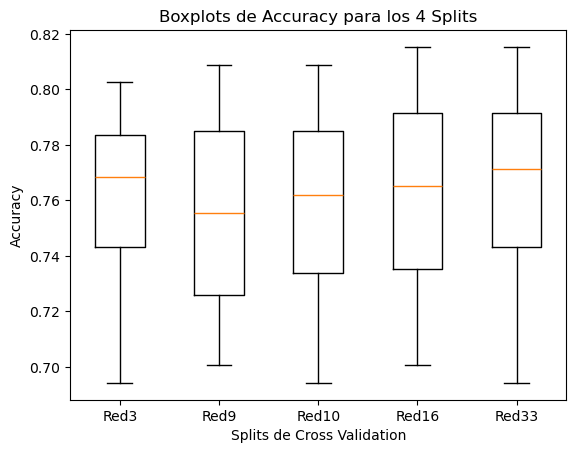

In [34]:
# Crear un boxplot para los cuatro valores de accuracy
plt.boxplot([ac_3.values,ac_9.values,ac_10.values,ac_16.values,ac_33.values], labels = ['Red3','Red9','Red10','Red16','Red33'])
plt.title('Boxplots de Accuracy para los 4 Splits')
plt.xlabel('Splits de Cross Validation')
plt.ylabel('Accuracy')
plt.show()

Parece que podemos descargar Red10 y Red16. Peor accuracy y más variabilidad.

In [36]:
print(MLPClassifier(**results.iloc[3].params))
print(MLPClassifier(**results.iloc[9].params))
print(MLPClassifier(**results.iloc[10].params))
print(MLPClassifier(**results.iloc[16].params))
print(MLPClassifier(**results.iloc[33].params))

MLPClassifier(activation='tanh', alpha=0.1, hidden_layer_sizes=6, max_iter=1000)
MLPClassifier(activation='tanh', alpha=0.001, hidden_layer_sizes=6,
              max_iter=1000)
MLPClassifier(activation='tanh', alpha=0.001, hidden_layer_sizes=7,
              max_iter=1000)
MLPClassifier(activation='tanh', hidden_layer_sizes=7, max_iter=1000)
MLPClassifier(hidden_layer_sizes=6, max_iter=1000)


Nuestras redes candidatas, con 6 nodos en la capa oculta, no están en el extremo de la parrilla, por lo que podemos a priori 'ahorrarnos' buscar otras parametrizaciones más complejas o sencillas

In [40]:
#hacemos más zoom sobre las redes que nos quedan
from sklearn.metrics import accuracy_score
#Hacemos las predicciones con ese modelo


red3 = MLPClassifier(**results.iloc[3].params)
red9 = MLPClassifier(**results.iloc[9].params)
red33 = MLPClassifier(**results.iloc[33].params)


# Ajustamos
red3.fit(X_train, y_train)
red9.fit(X_train, y_train)
red33.fit(X_train, y_train)

y3_pred_train = red3.predict(X_train)
y3_pred_test = red3.predict(X_test)

y9_pred_train = red9.predict(X_train)
y9_pred_test = red9.predict(X_test)

y33_pred_train = red33.predict(X_train)
y33_pred_test = red33.predict(X_test)

#Y vemos su accuracy
print(f"Accuracy en train 3- > {accuracy_score(y_true=y_train,y_pred=y3_pred_train)}")
print(f"Accuracy en test 3- > {accuracy_score(y_true=y_test,y_pred=y3_pred_test)}")


print(f"Accuracy en train 9- > {accuracy_score(y_true=y_train,y_pred=y9_pred_train)}")
print(f"Accuracy en test 9- > {accuracy_score(y_true=y_test,y_pred=y9_pred_test)}")

print(f"Accuracy en train 33- > {accuracy_score(y_true=y_train,y_pred=y33_pred_train)}")
print(f"Accuracy en test 33- > {accuracy_score(y_true=y_test,y_pred=y33_pred_test)}")

Accuracy en train 3- > 0.7599364069952306
Accuracy en test 3- > 0.7721518987341772
Accuracy en train 9- > 0.7599364069952306
Accuracy en test 9- > 0.7658227848101266
Accuracy en train 33- > 0.7583465818759937
Accuracy en test 33- > 0.759493670886076


Resultados similares, redes estables, ante la duda, nos quedamos con la red3, con menor variabilidad.